# Bootstrap del proceso completo

El error estándar que devuelve la regresión trata los 93 pares como un hecho
fijo. No lo son: los construimos con los mismos datos. En otra realización el
propensity score saldría distinto y el emparejamiento elegiría otros controles.
Ese brinco no está en ninguna fórmula analítica.

El bootstrap lo mete por la puerta de atrás: fabrica historias alternativas
remuestreando la muestra que tenemos, **rehace todo el proceso en cada una**
—logística, emparejamiento, estimación— y mide cuánto brinca el coeficiente
entre ellas. Es lo que pidió Alberto en el punto 3a, *"empezando con el cálculo
del propensity score"*.

Se corre sobre dos combinaciones:

| | Por qué |
| --- | --- |
| **300 m, todos los incidentes** | Es el radio que sostiene la tesis |
| **100 m, PIC** | Es la única de las 60 estimaciones que sale significativa, y con signo positivo. El bootstrap decide si sobrevive |

## Lo que se remuestrea, y lo que no

**Se remuestrean** las 99 unidades tratadas y el pool completo de controles, con
reemplazo. Sobre esa muestra se reajusta la logística, se rehace el
emparejamiento con las mismas reglas —caliper, Mahalanobis, separación— y se
reestima la especificación (3).

Se remuestrean las **99**, no las 93, porque en el pipeline las 99 compiten por
los controles y el recorte a la muestra común ocurre después. Reproducir ese
orden importa: si solo compitieran 93, encontrarían mejores controles de los que
les tocan en realidad.

**No se remuestrea** la intersección de los cinco radios. Las 93 se mantienen
fijas porque son la definición del estimando, y recalcularla en cada repetición
costaría cinco emparejamientos en vez de uno. Es una simplificación y hay que
declararla: el intervalo resultante **no** incorpora la incertidumbre de qué
unidades sobreviven en los cinco radios a la vez.

## Por qué se puede correr rápido

Lo caro del pipeline son los cruces espaciales —asignar incidentes a círculos,
medir metros de vía— y eso **no cambia** entre repeticiones: las covariables de
cada unidad y su serie mensual de incidentes ya están calculadas. Lo que hay que
rehacer es la logística y el emparejamiento, que son milisegundos.

La regresión también se acelera: en vez de armar 266 dummies, se aplica la
transformación intragrupo de dos vías. Sobre un panel balanceado da exactamente
el mismo coeficiente. Las dos celdas de verificación de abajo lo comprueban antes
de correr nada.

## Una advertencia teórica

Abadie e Imbens (2008) demostraron que el bootstrap no es formalmente válido para
estimadores de vecino más cercano con número fijo de vecinos: el emparejamiento
no es una función suficientemente suave de la distribución de los datos. Es parte
de por qué Alberto ofrece Sant'Anna y Zhao como alternativa. Lo que sigue es la
mejor aproximación disponible sin cambiar de estimador, no una solución exacta.


In [1]:
from nbsetup import *
from pipeline import Datos, muestra_comun, Panel, COVARIABLES
from pipeline.estimacion import COVARIABLES_FUERA
from scipy.spatial import cKDTree
from sklearn.linear_model import LogisticRegression

REPETICIONES = 500
SEMILLA = 0

datos = Datos()
emparejamientos, comunes = muestra_comun(datos)
print(f"{len(comunes)} tratadas comunes a los cinco radios")


93 tratadas comunes a los cinco radios


In [2]:
# precómputo: todo lo que NO cambia entre repeticiones
def preparar(emparejamiento, niveles=None):
    """Series mensuales, covariables y coordenadas, listas para remuestrear."""
    panel = Panel(emparejamiento, niveles=niveles)
    ps = emparejamiento.datos_ps                      # incluye logit_ps, x, y
    uids = ps.index.to_numpy()

    # serie mensual de cada unidad, incluidas las que nunca se emparejan
    inc = emparejamiento.features.incidentes_asignados
    if niveles is not None:
        inc = inc[inc.incident_level.isin(niveles)]
    i = np.searchsorted(panel.cortes, inc.timestamp, side="right") - 1
    ok = (i >= 0) & (i < len(panel.periodos))
    inc = inc[ok].assign(t=panel.periodos.t.values[i[ok]])

    serie = (inc.groupby(["uid", "t"]).peso.sum()
             .reindex(pd.MultiIndex.from_product([uids, panel.periodos.t],
                                                 names=["uid", "t"]), fill_value=0.0)
             .unstack("t").loc[uids].to_numpy())

    z = emparejamiento.Z.loc[uids].to_numpy()
    cov = emparejamiento.features.matriz.loc[uids, panel.covariables]
    zcov = ((cov - cov.mean()) / cov.std()).to_numpy()

    return {
        "uids": uids,
        "tratado": (ps.tratado == 1).to_numpy(),
        "z": z,
        "zcov": zcov,
        "xy": ps[["x", "y"]].to_numpy(),
        "serie": serie,
        "post": panel.periodos.post.to_numpy().astype(float),
        "caliper_sd": emparejamiento.caliper_sd,
        "separacion": 2 * emparejamiento.radio_m,
        "comunes": np.array([u in comunes for u in uids]),
        "panel": panel,
    }


In [3]:
# el emparejamiento y la estimación, reimplementados para correr en el bucle
def emparejar(z, tratado, xy, caliper_sd, separacion, orden_tratadas=None):
    """Vecino más cercano 1:1 sin reemplazo, igual que `Emparejamiento`."""
    modelo = LogisticRegression(max_iter=5000, C=np.inf,
                                solver="newton-cholesky").fit(z, tratado)
    ps = modelo.predict_proba(z)[:, 1]
    logit = np.log(ps / (1 - ps))
    caliper = caliper_sd * logit.std(ddof=1)
    inv_cov = np.linalg.pinv(np.cov(z.T))

    idx_t = np.where(tratado)[0]
    idx_t = idx_t[np.argsort(-ps[idx_t])]          # las más difíciles eligen primero
    idx_c = np.where(~tratado)[0]
    c_logit, c_xy, c_z = logit[idx_c], xy[idx_c], z[idx_c]

    disponible = np.ones(len(idx_c), dtype=bool)
    ocupados, pares = [], []
    for i in idx_t:
        d_ps = np.abs(c_logit - logit[i])
        elegibles = disponible & (d_ps <= caliper)
        if ocupados:
            elegibles &= cKDTree(np.array(ocupados)).query(c_xy)[0] >= separacion
        if not elegibles.any():
            continue
        cand = np.where(elegibles)[0]
        dif = c_z[cand] - z[i]
        maha = np.einsum("ij,jk,ik->i", dif, inv_cov, dif)
        elegido = cand[np.argmin(maha)]
        pares.append((i, idx_c[elegido]))
        ocupados.append(c_xy[elegido])
        disponible[elegido] = False
    return np.array(pares, dtype=int).reshape(-1, 2)


def coeficiente(pares, serie, zcov, post):
    """Especificación (3) por transformación intragrupo de dos vías."""
    filas = np.concatenate([pares[:, 0], pares[:, 1]])
    n = len(filas)
    y = serie[filas]
    tratado = np.concatenate([np.ones(len(pares)), np.zeros(len(pares))])

    D = tratado[:, None] * post[None, :]
    X = [D] + [zcov[filas, k][:, None] * post[None, :] for k in range(zcov.shape[1])]

    def dentro(a):
        return a - a.mean(1, keepdims=True) - a.mean(0, keepdims=True) + a.mean()

    Xd = np.column_stack([dentro(a).ravel() for a in X])
    yd = dentro(y).ravel()
    return np.linalg.lstsq(Xd, yd, rcond=None)[0][0]


In [4]:
# VERIFICACIÓN: la reimplementación tiene que reproducir el pipeline
for radio, niveles, etiqueta in [(300, None, "300 m, todos"), (100, ("PIC",), "100 m, PIC")]:
    d = preparar(emparejamientos[radio], niveles)

    pares = emparejar(d["z"], d["tratado"], d["xy"], d["caliper_sd"], d["separacion"])
    pares = pares[d["comunes"][pares[:, 0]]]        # el recorte a la muestra común

    del_pipeline = emparejamientos[radio].pares
    mismos = set(map(tuple, d["uids"][pares])) == set(
        zip(del_pipeline.tratada, del_pipeline.control))

    coef = coeficiente(pares, d["serie"], d["zcov"], d["post"])
    esperado = d["panel"].estimar(d["panel"].especificaciones["(3) + covariables x post"])["coef"]

    print(f"{etiqueta:<14} pares {len(pares):>3} (pipeline {len(del_pipeline)}) | "
          f"mismos pares: {mismos} | coef {coef:+.6f} vs {esperado:+.6f} "
          f"| dif {abs(coef - esperado):.2e}")
    assert mismos and abs(coef - esperado) < 1e-8, "la reimplementación no coincide"

print("\nlas dos reimplementaciones reproducen el pipeline")


300 m, todos   pares  93 (pipeline 93) | mismos pares: True | coef -0.106328 vs -0.106328 | dif 7.11e-14


100 m, PIC     pares  93 (pipeline 93) | mismos pares: True | coef +0.084752 vs +0.084752 | dif 1.80e-14

las dos reimplementaciones reproducen el pipeline


In [5]:
# el bootstrap
def bootstrap(d, repeticiones=REPETICIONES, semilla=SEMILLA):
    """Remuestrea unidades, rehace logística y emparejamiento, reestima."""
    rng = np.random.default_rng(semilla)
    idx_t = np.where(d["tratado"])[0]
    idx_c = np.where(~d["tratado"])[0]

    coeficientes, n_pares = [], []
    for _ in range(repeticiones):
        sel = np.concatenate([rng.choice(idx_t, len(idx_t), replace=True),
                              rng.choice(idx_c, len(idx_c), replace=True)])
        pares = emparejar(d["z"][sel], d["tratado"][sel], d["xy"][sel],
                          d["caliper_sd"], d["separacion"])
        if not len(pares):
            continue
        original = sel[pares]                       # índices en la muestra original
        pares = pares[d["comunes"][original[:, 0]]]
        if len(pares) < 10:
            continue
        filas = sel[pares]
        coeficientes.append(coeficiente(filas, d["serie"], d["zcov"], d["post"]))
        n_pares.append(len(pares))

    return np.array(coeficientes), np.array(n_pares)


In [6]:
# correrlo
import time

resultados_bootstrap = {}
for radio, niveles, etiqueta in [(300, None, "300 m, todos"), (100, ("PIC",), "100 m, PIC")]:
    d = preparar(emparejamientos[radio], niveles)
    t0 = time.time()
    coefs, n_pares = bootstrap(d)
    p = d["panel"]
    fila = p.estimar(p.especificaciones["(3) + covariables x post"])
    resultados_bootstrap[etiqueta] = {
        "coef": fila["coef"], "EE_analitico": fila["EE"], "sig_analitico": fila["sig"],
        "media_control": fila["media_control"],
        "EE_bootstrap": coefs.std(ddof=1),
        "ic_bajo": np.percentile(coefs, 2.5), "ic_alto": np.percentile(coefs, 97.5),
        "repeticiones": len(coefs), "pares_mediana": int(np.median(n_pares)),
        "segundos": time.time() - t0,
    }
    resultados_bootstrap[etiqueta]["_coefs"] = coefs

tabla = pd.DataFrame({k: {a: b for a, b in v.items() if a != "_coefs"}
                      for k, v in resultados_bootstrap.items()}).T
tabla["razon_EE"] = tabla.EE_bootstrap / tabla.EE_analitico
tabla["cruza_cero"] = (tabla.ic_bajo < 0) & (tabla.ic_alto > 0)
tabla.round(4)


,coef,EE_analitico,sig_analitico,media_control,EE_bootstrap,ic_bajo,ic_alto,repeticiones,pares_mediana,segundos,razon_EE,cruza_cero
"300 m, todos",-0.106328,0.180839,,6.019415,0.124391,-0.373143,0.101736,500,93,160.721682,0.687858,True
"100 m, PIC",0.084752,0.04164,**,0.889486,0.041574,-0.037104,0.123665,500,92,156.477103,0.998411,True


In [7]:
# lectura
for etiqueta, r in resultados_bootstrap.items():
    cm = r["media_control"]
    print(f"{etiqueta}")
    print(f"  coeficiente          {r['coef']:+.4f}  ({100*r['coef']/cm:+.2f}% del control)")
    print(f"  EE analítico         {r['EE_analitico']:.4f}   {r['sig_analitico'] or '(no significativo)'}")
    print(f"  EE bootstrap         {r['EE_bootstrap']:.4f}   ({r['EE_bootstrap']/r['EE_analitico']:.2f}x)")
    print(f"  IC 95% percentil     [{r['ic_bajo']:+.4f}, {r['ic_alto']:+.4f}]"
          f"  =  [{100*r['ic_bajo']/cm:+.1f}%, {100*r['ic_alto']/cm:+.1f}%]")
    print(f"  ¿cruza cero?         {'sí' if r['ic_bajo'] < 0 < r['ic_alto'] else 'NO'}")
    print(f"  {r['repeticiones']} repeticiones, mediana de {r['pares_mediana']} pares, "
          f"{r['segundos']:.0f} s")
    print()


300 m, todos
  coeficiente          -0.1063  (-1.77% del control)
  EE analítico         0.1808   (no significativo)
  EE bootstrap         0.1244   (0.69x)
  IC 95% percentil     [-0.3731, +0.1017]  =  [-6.2%, +1.7%]
  ¿cruza cero?         sí
  500 repeticiones, mediana de 93 pares, 161 s

100 m, PIC
  coeficiente          +0.0848  (+9.53% del control)
  EE analítico         0.0416   **
  EE bootstrap         0.0416   (1.00x)
  IC 95% percentil     [-0.0371, +0.1237]  =  [-4.2%, +13.9%]
  ¿cruza cero?         sí
  500 repeticiones, mediana de 92 pares, 156 s



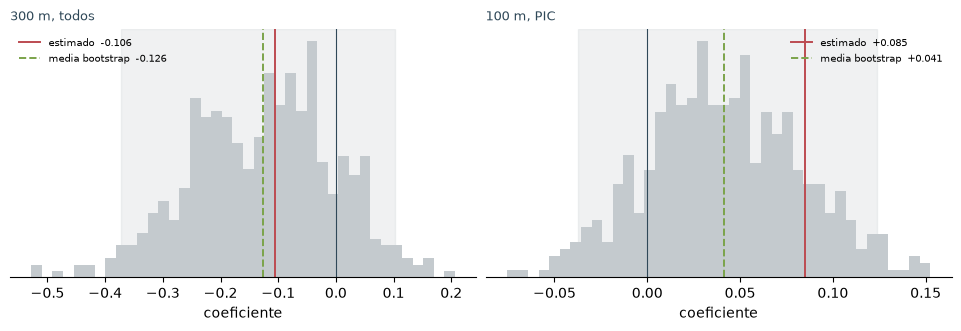

300 m, todos
  estimado original  -0.1063
  media bootstrap    -0.1256
  sesgo              -0.0193
  percentil del original en la distribución: 53
  repeticiones con signo contrario al original: 16%

100 m, PIC
  estimado original  +0.0848
  media bootstrap    +0.0412
  sesgo              -0.0436
  percentil del original en la distribución: 84
  repeticiones con signo contrario al original: 15%



In [8]:
# el sesgo: dónde cae el estimado original dentro de la distribución bootstrap
TRATADA, CONTROL, TINTA, GRIS = "#BC4B51", "#7BA34A", "#2F4858", "#C4CACE"
fig, axes = plt.subplots(1, 2, figsize=(9.5, 3.2), layout="constrained")

for ax, (etiqueta, r) in zip(axes, resultados_bootstrap.items()):
    c = r["_coefs"]
    ax.hist(c, bins=40, color=GRIS, edgecolor="none")
    ax.axvline(0, color=TINTA, lw=.8)
    ax.axvline(r["coef"], color=TRATADA, lw=1.4, label=f"estimado  {r['coef']:+.3f}")
    ax.axvline(c.mean(), color=CONTROL, lw=1.4, ls="--", label=f"media bootstrap  {c.mean():+.3f}")
    ax.axvspan(r["ic_bajo"], r["ic_alto"], color=GRIS, alpha=.25, zorder=0)
    ax.set_title(etiqueta, fontsize=9, loc="left", color=TINTA)
    ax.set_xlabel("coeficiente")
    ax.legend(frameon=False, fontsize=7.5)
    ax.spines[["top", "right", "left"]].set_visible(False)
    ax.set_yticks([])
plt.show()

for etiqueta, r in resultados_bootstrap.items():
    c = r["_coefs"]
    print(f"{etiqueta}")
    print(f"  estimado original  {r['coef']:+.4f}")
    print(f"  media bootstrap    {c.mean():+.4f}")
    print(f"  sesgo              {c.mean() - r['coef']:+.4f}")
    print(f"  percentil del original en la distribución: {100*(c < r['coef']).mean():.0f}")
    print(f"  repeticiones con signo contrario al original: {100*(np.sign(c) != np.sign(r['coef'])).mean():.0f}%")
    print()
